<a href="https://colab.research.google.com/github/jrlewis-umbc/MPLNET/blob/python/mplnet_map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   **Module:** mplnet_map.ipynb
*   **Purpose:** To make maps of MPLNET sites and data
*   **Author(s):** Sophia Summers, Jasper Lewis








Import necessary modules

In [ ]:
!pip install cartopy
!pip install folium

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import folium
import mapclassify
import requests
import io
import xarray as xr
import numpy as np
from google.colab import files

Customize inputs and retrieve site locations from Web Services API

In [28]:
version = "V3"                  # Enter V2 or V3
level = "L1"                    # Enter L1, L15, or L2 (if available)
product = "Status"              # Enter Status, NRB, CLD, AER, or PBL (Note: If "Status" is chosen other inputs are ignored)
start_date_str = None     # Enter in YYYYMMDD format or None to plot all MPLNET sites
end_date_str = "20240531"       # Enter in YYYYMMDD format
var = "aod"               #Variable to plot (aod, angstrom_exponent, lidar_ratio, sunphoto_lidar_ratio, aodprf, backscatter, backscatter_ratio, extinction)
altitude = None           #If you want to look at a value for specific altitude for a 2D variable, enter a value here
altitude_min = None       #If you want to look at a value averaged/integrated over a specific altitude range, add minimum value of interest here
altitude_max = None       #If you want to look at a value averaged/integrated over a specific altitude range, add maximum value of interest here
statistic = "integrated"  #If you want to look at a value averaged over a specific altitude range, write "averaged" here. If you want to look at a value integrated over a specific altitude range, write "integrated" here.
confidence = None         #"high", "moderate", "low", or None
day_or_night = None       #"day", "night", or None if you want to look at all times
map_lons = [-90, -60]
map_lats = [30, 50]

if product == "Status":
  if start_date_str is None:
    #Create a dataframe containing site information
    csv_url = "https://mplnet.gsfc.nasa.gov/operations/sites?api&sites=all&format=csv"
  else:
    #Create a dataframe containing site information
    start_date_str = start_date_str.replace("-","").replace("/","").replace(" ","")
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    yyyy = start_date.strftime("%Y")
    mm = start_date.strftime("%m")
    csv_url = "https://mplnet.gsfc.nasa.gov/operations/sites?api&sites=all&year="+yyyy+"&month="+mm+"&format=csv"

else:
  # Ensure inputs match the expected format
  start_date_str = start_date_str.replace("-","").replace("/","").replace(" ","")
  end_date_str = end_date_str.replace("-","").replace("/","").replace(" ","")
  start_date = datetime.strptime(start_date_str, "%Y%m%d")
  end_date = datetime.strptime(end_date_str, "%Y%m%d")
  delta = timedelta(days=1)

  level = str(level).replace(".","")
  product = product.upper()
  statistic = statistic.lower()
  var = var.lower()
  qa_var = "qa_"+var

  if confidence is not None:
    confidence = confidence.lower()

  if day_or_night is not None:
    day_or_night = day_or_night.lower()

  yyyy = start_date.strftime("%Y")
  mm = start_date.strftime("%m")
  csv_url = "https://mplnet.gsfc.nasa.gov/operations/sites?api&sites=all&year="+yyyy+"&month="+mm+"&format=csv"

site_df = pd.read_csv(csv_url)


This next module is only for product other than "Status". Otherwise skip to make plot module.

In [ ]:
if product != "Status":
  results = []
  for _, site_row in site_df.iterrows():
    site = site_row["Site"]
    current_date = start_date

    if day_or_night is not None:
      while current_date <= end_date:
        yyyy = current_date.strftime("%Y")
        mm = current_date.strftime("%m")
        dd = current_date.strftime("%d")
        data_url = 'https://mplnet.gsfc.nasa.gov/download?version='+version+'&level='+level+'&product='+product+'&site='+site+"&year="+yyyy+"&month="+mm+"&day="+dd
        day_url = 'https://mplnet.gsfc.nasa.gov/download?version='+version+'&level='+level+'&product=CLD&site='+site+"&year="+yyyy+"&month="+mm+"&day="+dd

        response = requests.get(data_url)   #retrieves data from the URL
        response.raise_for_status()   #confirms that the URL exists

        day_response = requests.get(day_url)   #retrieves CLD product data
        day_response.raise_for_status()

        try:
          file_bytes = io.BytesIO(response.content)
          ds = xr.open_dataset(file_bytes, engine = "h5netcdf", decode_times = False) #opens a dataset

          day_file_bytes = io.BytesIO(day_response.content)
          day_ds = xr.open_dataset(day_file_bytes, engine = "h5netcdf", decode_times = False) #opens CLD product dataset

          if var not in ds:
            current_date += delta
            ds.close() #closes the dataset
            continue

          if "day_indicator" in day_ds:
            #Create a mask using the day_indicator variable
            if day_or_night == "day":
              day_mask = day_ds["day_indicator"] == 2
            elif day_or_night == "night":
              day_mask = day_ds["day_indicator"] == 1
            #Apply the mask
            ds = ds.where(day_mask)
          else:
            print(f"Warning: 'day_indicator' not found in CLD product for {current_date.strftime('%Y-%m-%d')}. No day/night screening applied.")

          var_values = ds[var]

          if qa_var in ds and confidence is not None:
            qa = ds[qa_var].squeeze()

            if confidence == "high":
              good = qa == 1

            elif confidence == "moderate":
              good = qa <= 2

            elif confidence == "low":
              good = qa <=4

            var_values = var_values.where(good) #applies a mask to the data so that we only look at data of the given confidence level

          if var_values.ndim == 3 and altitude is not None: #If we have a 2D variable and we want to look at a specific altitude
            alt = ds["altitude"]
            var_values = ds[var].squeeze("wavelength")
            index = abs(alt - altitude).argmin(dim="altitude") #finds the index of the altitude with measurements closest to the target altitude
            value_at_altitude = var_values.isel(altitude = index)
            site_value = value_at_altitude.mean().item() #finds the average value at that altitude over a given period of time
            results.append({"Site": site, "Date": current_date, "Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: site_value})

          elif var_values.ndim == 3 and altitude_min is not None and altitude_max is not None:  #If we have a 2D variable and we want to integrate/average over a range of altitudes
            alt = ds["altitude"].isel(time=0).values
            var_values = ds[var].squeeze("wavelength").values
            mask = ((alt>=altitude_min) & (alt<=altitude_max))
            index = np.where(mask)[0]
            layer = var_values[:, index]
            layer_alts = alt[index]

            if statistic == "averaged":
             value_for_range = np.nanmean(layer) #takes the mean value through that altitude range

            elif statistic == "integrated":
              value_for_range = np.trapezoid(np.nan_to_num(layer, nan=0.0), x=layer_alts, axis=1).mean().item() #integrates over the altitude range using the trapezoid rule

            site_value = value_for_range
            results.append({"Site": site, "Date": current_date, "Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: site_value})

          else:
            mean_var = ds[var].mean().item() #finds the mean value of the variable of interest for that day
            results.append({"Site": site, "Date": current_date,"Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: mean_var})
          ds.close() #closes the dataset

        except Exception as e:
          current_date += delta
          continue

        current_date += delta

    else:
      day_or_night = ""
      while current_date <= end_date:
        year = current_date.strftime("%Y")
        month = current_date.strftime("%m")
        day = current_date.strftime("%d")
        data_url = 'https://mplnet.gsfc.nasa.gov/download?version=V'+str(version)+'&level=L'+str(level)+'&product='+product+'&site='+site+"&year="+year+"&month="+month+"&day="+day
        response = requests.get(data_url)   #retrieves data from the URL
        response.raise_for_status()   #confirms that the URL exists

        try:
          file_bytes = io.BytesIO(response.content)
          ds = xr.open_dataset(file_bytes, engine = "h5netcdf", decode_times = False) #opens a dataset

          if var not in ds:
            current_date += delta
            ds.close() #closes the dataset
            continue

          var_values = ds[var]

          if qa_var in ds and confidence is not None:
            qa = ds[qa_var].squeeze()

            if confidence == "high":
              good = qa == 1

            elif confidence == "moderate":
              good = qa <= 2

            elif confidence == "low":
              good = qa <=4

            var_values = var_values.where(good) #applies a mask to the data so that we only look at data of the given confidence level


          if var_values.ndim == 3 and altitude is not None: #If we have a 2D variable and we want to look at a specific altitude
            alt = ds["altitude"]
            var_values = ds[var].squeeze("wavelength")
            index = abs(alt - altitude).argmin(dim="altitude") #finds the index of the altitude with measurements closest to the target altitude
            value_at_altitude = var_values.isel(altitude = index)
            site_value = value_at_altitude.mean().item() #finds the average value at that altitude over a given period of time
            results.append({"Site": site, "Date": current_date, "Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: site_value})

          elif var_values.ndim == 3 and altitude_min is not None and altitude_max is not None:  #If we have a 2D variable and we want to integrate/average over a range of altitudes
            alt = ds["altitude"].isel(time=0).values
            var_values = ds[var].squeeze("wavelength").values
            mask = ((alt>=altitude_min) & (alt<=altitude_max))
            index = np.where(mask)[0]
            layer = var_values[:, index]
            layer_alts = alt[index]

            if statistic == "averaged":
              value_for_range = np.nanmean(layer) #takes the mean value through that altitude range

            elif statistic == "integrated":
              value_for_range = np.trapezoid(np.nan_to_num(layer, nan=0.0), x=layer_alts, axis=1).mean().item() #integrates over the altitude range using the trapezoid rule

            site_value = value_for_range
            results.append({"Site": site, "Date": current_date, "Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: site_value})

          else:
            mean_var = ds[var].mean().item() #finds the mean value of the variable of interest for that day
            results.append({"Site": site, "Date": current_date,"Latitude": site_row["Latitude"], "Longitude": site_row["Longitude"], var: mean_var})
          ds.close() #closes the dataset

        except Exception as e:
          current_date += delta
          continue

        current_date += delta

  results_df = pd.DataFrame(results)

Make map

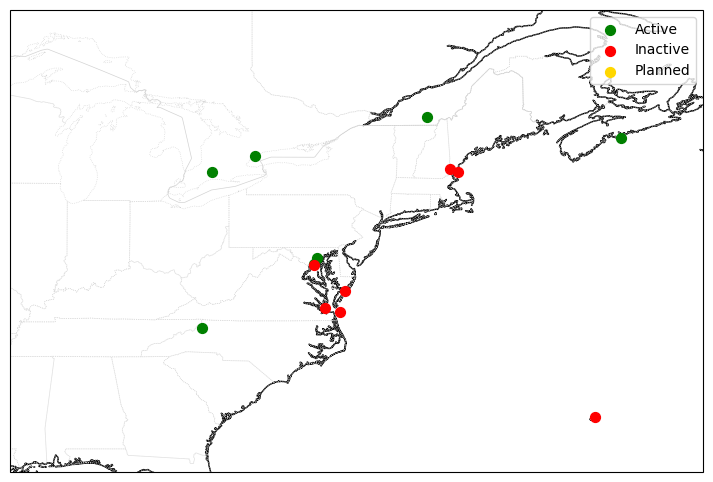

In [30]:
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

#Add features to the map
ax.coastlines(resolution='10m',zorder=0)
ax.add_feature(cfeature.STATES.with_scale('10m'), linestyle = ":", linewidth=0.5, edgecolor='lightgray',zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5, edgecolor='lightgray',zorder=0)

if product == "Status":
  scatter_plot = ax.scatter(
    (site_df["Longitude"])[site_df["Current_Status"]=="Active"],
    (site_df["Latitude"])[site_df["Current_Status"]=="Active"],
    color="green",
    label="Active",
    s=50,
    transform=ccrs.PlateCarree()
  )

  scatter_plot = ax.scatter(
    (site_df["Longitude"])[site_df["Current_Status"]=="Inactive"],
    (site_df["Latitude"])[site_df["Current_Status"]=="Inactive"],
    color="red",
    label="Inactive",
    s=50,
    transform=ccrs.PlateCarree()
  )

  scatter_plot = ax.scatter(
    (site_df["Longitude"])[site_df["Current_Status"]=="Planned"],
    (site_df["Latitude"])[site_df["Current_Status"]=="Planned"],
    color="gold",
    label="Planned",
    s=50,
    transform=ccrs.PlateCarree()
  )
else:
  average_df = (results_df.groupby(["Site", "Latitude", "Longitude"], as_index=False)[var].mean()) #stores the average across the dates of interest
  geometry = [Point(xy) for xy in zip(site_df["Longitude"], site_df["Latitude"])]
  gdf = gpd.GeoDataFrame(site_df, geometry=geometry)
  gdf.set_crs(epsg=4326, inplace=True)

  scatter_plot = ax.scatter(
      average_df["Longitude"],
      average_df["Latitude"],
      c=average_df[var],
      cmap="turbo",
      transform=ccrs.PlateCarree()
  )
  fig.colorbar(scatter_plot, ax=ax, orientation="vertical", label=var)
  if start_date_str == end_date_str:
    if altitude is not None:
      plt.title("MPLNET "+var+" at "+str(altitude) +"km "+start_date_str+" "+day_or_night)
    elif altitude_min is not None and altitude_max is not None:
      plt.title("MPLNET "+var+" "+statistic+" from "+str(altitude_min) +"km to "+str(altitude_max)+"km "+start_date_str+" "+day_or_night)
    else:
      plt.title("MPLNET "+var+" "+start_date_str+" "+day_or_night)
  else:
    if altitude is not None:
      plt.title("MPLNET "+var+" at "+str(altitude) +"km "+start_date_str+" to "+end_date_str+" "+day_or_night)
    elif altitude_min is not None and altitude_max is not None:
      plt.title("MPLNET "+var+" "+statistic+" from "+str(altitude_min) +"km to "+str(altitude_max)+"km "+start_date_str+" to "+end_date_str+" "+day_or_night)
    else:
      plt.title("MPLNET "+var+" "+start_date_str+" to "+end_date_str+" "+day_or_night)

ax.set_xlim(map_lons)
ax.set_ylim(map_lats)
plt.legend()
title = plt.gca().get_title()
plt.savefig(title+".png", bbox_inches="tight", dpi=300)
plt.show()